# Tutorial 1 — The SlotFlow idea in miniature: catalogues, slots, and why ordering breaks

**The lesson of this session, in one sentence:**

> *A model predicts the correct set only when the training objective
> respects the symmetry of the problem.*

We work with **toy spectral sources** — 1-D mixtures of narrow Gaussian
peaks. They are *not* LISA waveforms; the connection to LISA is that both
problems require inferring an **unordered catalogue** from a superposition:

$$x(f) = \sum_{k=1}^{K} A_k \exp\!\left[-\frac{(f-\mu_k)^2}{2\sigma^2}\right] + n(f),
\qquad \theta_k = (\mu_k, A_k),\ \sigma\ \text{fixed}.$$

| when | what |
|---|---|
| 0–4′ | setup (run the next cell now) |
| 4–8′ | **§1** inspect mixtures, make human guesses |
| 8–14′ | **§2** train the deliberately *broken* ordered-loss model |
| 14–17′ | **§3a** match a 3×3 cost matrix by hand — beat greedy |
| 17–26′ | **§3b** implement the Hungarian loss *(the only TODO)* |
| 26–32′ | **§4** retrain permutation-invariantly; compare |
| 32–37′ | **§5** when does assignment become ambiguous? *(presenter-driven)* |
| 37–40′ | **§6** takeaways, concept map, bridge to Tutorial 2 |

**What you will actually DO (everything else is run-a-cell-and-look):**

* §1 — write down your (μ, A) guesses for five mixtures *(~2 min)*
* §3a — type your picks into `my_assignment`, try to beat greedy *(~1 min)*
* **§3b — the one coding task of this session: the Hungarian-loss TODO**

Throughout: **truth = ▼, predictions = ○.** Every training cell has a
checkpoint fallback (`TRAIN_LIVE = False`), so nobody can get stranded.

In [1]:
# --- Setup: works locally and on Google Colab ----------------------------
import os, sys
if not os.path.exists("viz.py"):                      # locate the materials
    if os.path.exists("workshop/viz.py"):               # started at repo root
        os.chdir("workshop")
    else:                                               # Colab: fetch the repo
        REPO_URL = "https://github.com/nhouba/slotflow-inference.git"
        os.system(f"git clone --depth 1 {REPO_URL} slotflow-repo")
        os.chdir("slotflow-repo/workshop")
sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib.pyplot as plt
import torch

import viz                                   # shared workshop style
from viz import C, mark_truth, mark_pred, title2
from toy.simulator import (make_dataset, make_mixture, render,
                           FREQ_AXIS, SIGMA, NOISE_STD)

np.set_printoptions(precision=3, suppress=True)
print("ready:", os.getcwd())

ready: /Users/lorenzo.speri/Library/CloudStorage/OneDrive-ESA/Documents/GitHub/LISAI/tutorials/niklas-houba


## §1 — You be the catalogue: five mixtures, write down your answers

The simulator is a few readable lines — open `toy/simulator.py` if
curious. Below are five mixtures, easy to cruel. **For each panel write
down your catalogue: (μ, A) for both sources** — then discuss with your
neighbour: which panels are ambiguous, and *why*? And one more question:
the targets arrive as a list $[\theta_1, \theta_2]$ — why is that order
arbitrary?

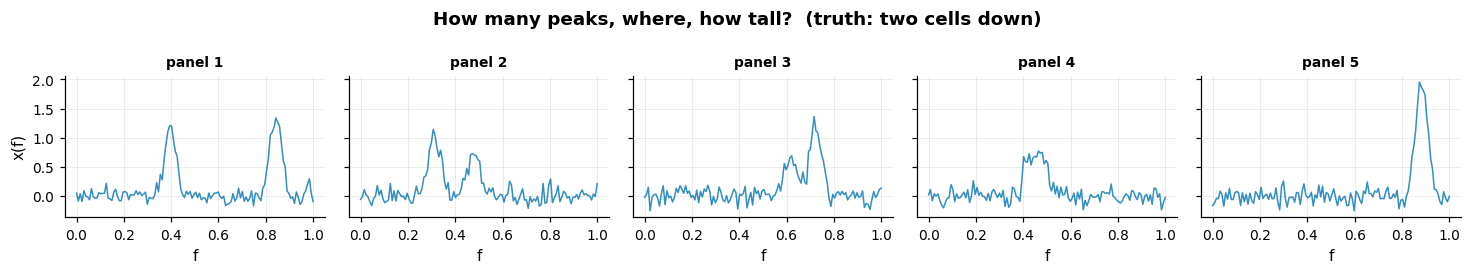

In [2]:
# --- Human-vs-machine: write down your (mu, A) guesses for these five ----
rng_h = np.random.default_rng(42)
_hidden = []
fig, axes = plt.subplots(1, 5, figsize=(13.5, 2.5), sharey=True)
seps = [(0.3, 0.6), (0.15, 0.3), (0.07, 0.12), (0.03, 0.07), (0.0, 0.03)]
for k, (ax, sep) in enumerate(zip(axes, seps), 1):
    x, theta = make_mixture(rng_h, sep_range=sep)
    _hidden.append(theta)
    ax.plot(FREQ_AXIS, x, lw=1, color=C["pred"], alpha=0.8)
    ax.set_xlabel("f")
    ax.set_title(f"panel {k}", fontsize=9)
axes[0].set_ylabel("x(f)")
fig.suptitle("How many peaks, where, how tall?  (truth: two cells down)",
             fontweight="semibold")
plt.tight_layout()

In [3]:
for i, theta in enumerate(_hidden):
    order = np.argsort(theta[:, 0])
    print(f"panel {i+1}: " + "   ".join(
        f"(mu={mu:.2f}, A={A:.2f})" for mu, A in theta[order]))
print("\nThe rightmost panels are genuinely ambiguous — remember them; "
      "\nassignment ambiguity returns in §5 and again for LISA in Tutorial 2.")

panel 1: (mu=0.40, A=1.14)   (mu=0.84, A=1.32)
panel 2: (mu=0.31, A=1.02)   (mu=0.48, A=0.83)
panel 3: (mu=0.61, A=0.63)   (mu=0.72, A=1.28)
panel 4: (mu=0.42, A=0.62)   (mu=0.48, A=0.63)
panel 5: (mu=0.88, A=0.79)   (mu=0.89, A=1.23)

The rightmost panels are genuinely ambiguous — remember them; 
assignment ambiguity returns in §5 and again for LISA in Tutorial 2.


## §2 — Train the *broken* ordered model

The obvious objective compares slot $i$ to target $i$:

$$\mathcal{L}_{\rm ordered} = \sum_{i=1}^{2} \lVert \hat\theta_i - \theta_i \rVert^2 .$$

Our targets are **randomly permuted per example** (they are i.i.d. draws,
so their order carries no information either way — the shuffle just makes
that impossible to forget).

One rule we adopt from the start: **evaluation is always permutation-
matched**, whatever the training loss does. The monitor below imports the
reference matched metric from `toy/model.py` — *you* will implement your
own in §3.

**Before running: predict what the trained model will do.** Training takes
~10 s on a laptop CPU.

In [4]:
from toy.model import ToySlotNet, ordered_loss
from toy import model as _reference          # matched metric for MONITORING only

train_npz = np.load("toy/data/toy_train.npz")
val_npz = np.load("toy/data/toy_val.npz")
X, T = torch.from_numpy(train_npz["X"]), torch.from_numpy(train_npz["T"])
Xv, Tv = torch.from_numpy(val_npz["X"]), torch.from_numpy(val_npz["T"])
print(f"train {tuple(X.shape)}   val {tuple(Xv.shape)}")

VAL_SUB = 256      # matched-val monitor subset (keeps epochs fast)


def fit(net, loss_fn, epochs=12, batch=128, lr=2e-3, tag=""):
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    hist = {"train": [], "val": []}
    for ep in range(epochs):
        perm = torch.randperm(len(X))
        tot = 0.0
        for i in range(0, len(X), batch):
            idx = perm[i:i + batch]
            loss = loss_fn(net(X[idx]), T[idx])
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item() * len(idx)
        hist["train"].append(tot / len(X))
        with torch.no_grad():
            hist["val"].append(_reference.hungarian_loss(
                net(Xv[:VAL_SUB]), Tv[:VAL_SUB]).item())
        # print the first epochs too — that's where the descent happens
        if ep < 2 or (ep + 1) % 4 == 0:
            print(f"  [{tag}] epoch {ep+1:2d}/{epochs}   "
                  f"train {hist['train'][-1]:.4f}   "
                  f"matched val {hist['val'][-1]:.4f}")
    return hist


TRAIN_LIVE = True    # False -> load toy/data/after_ordered.pt instead

torch.manual_seed(0)
net_ordered = ToySlotNet()
if TRAIN_LIVE:
    hist_ordered = fit(net_ordered, ordered_loss, tag="ordered")
else:
    ck = torch.load("toy/data/after_ordered.pt", weights_only=False)
    net_ordered.load_state_dict(ck["state_dict"])
    hist_ordered = None
    print("loaded staged checkpoint (30 epochs)")

train (8000, 128)   val (1000, 128)
  [ordered] epoch  1/12   train 0.4476   matched val 0.1942
  [ordered] epoch  2/12   train 0.1618   matched val 0.1351
  [ordered] epoch  4/12   train 0.1456   matched val 0.1279
  [ordered] epoch  8/12   train 0.1416   matched val 0.1238
  [ordered] epoch 12/12   train 0.1397   matched val 0.1261


mean |mu_slot1 - mu_slot2| = 0.034   (true peaks are 0.269 apart on average)


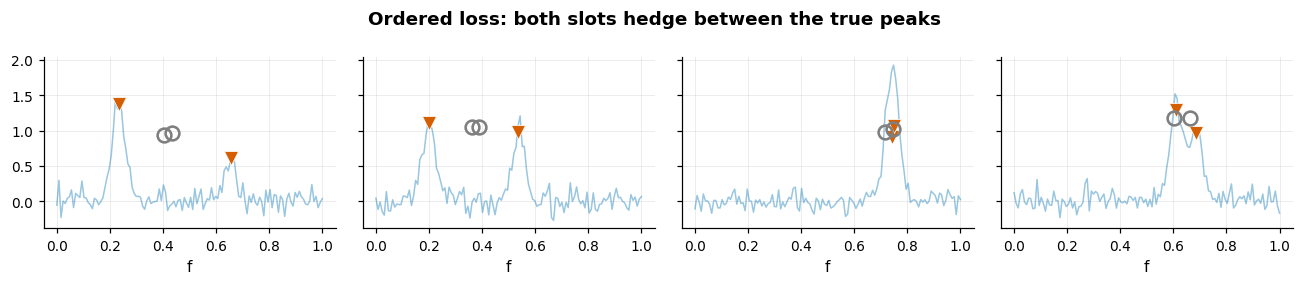

In [5]:
def show_predictions(net, title, n=4, seed=1, color=C["pred"], recon=False):
    net.eval()
    with torch.no_grad():
        P = net(Xv[:200])
    fig, axes = plt.subplots(1, n, figsize=(3.0 * n, 2.6), sharey=True)
    rng_v = np.random.default_rng(seed)
    for ax, i in zip(axes, rng_v.choice(200, n, replace=False)):
        ax.plot(FREQ_AXIS, Xv[i], lw=1, color=C["pred"], alpha=0.4)
        if recon:
            ax.plot(FREQ_AXIS, render(P[i].numpy()), ls=":", lw=1.4,
                    color=color)
        for mu, A in Tv[i]:
            mark_truth(ax, mu, A)
        for mu, A in P[i]:
            mark_pred(ax, mu, A, color=color)
        ax.set_xlabel("f")
    fig.suptitle(title, fontweight="semibold")
    plt.tight_layout()
    return fig


show_predictions(net_ordered, "Ordered loss: both slots hedge between "
                 "the true peaks", color=C["ordered"]);

with torch.no_grad():
    P = net_ordered(Xv)
gap_pred = (P[:, 0, 0] - P[:, 1, 0]).abs().mean()
gap_true = (Tv[:, 0, 0] - Tv[:, 1, 0]).abs().mean()
print(f"mean |mu_slot1 - mu_slot2| = {gap_pred:.3f}   "
      f"(true peaks are {gap_true:.3f} apart on average)")

**What you should see:** the loss falls fast for two epochs (~0.45 → 0.15)
and then goes **flat near 0.14** — while the plots show both slots
predicting *the same point, between the two true peaks* (slot separation
≈ 0.03 vs true separation ≈ 0.27), even though a human knows exactly where
both peaks are.

**The plateau is not a training problem — it is a floor you can compute.**
With randomly ordered targets, slot $i$ sees either source with
probability ½, and the MSE-optimal prediction under that coin flip is the
per-example average of the two sources. The expected loss of that hedge is

$$\mathbb{E}\big[\tfrac{1}{2}\lVert\theta_1-\theta_2\rVert^2\big]
= \mathrm{Var}(\mu) + \mathrm{Var}(A)
= \tfrac{0.8^2}{12} + \tfrac{1^2}{12} \approx 0.137
\quad\text{for our priors,}$$

which is exactly where the curve sits. More epochs or more data cannot
push below it (the 30-epoch staged checkpoint plateaus at the same value)
— **the objective, not the network or the optimizer, is broken.** That is
the diagnosis a loss curve alone would never give you.

## §3a — Matching by hand: beat the greedy strategy

The fix will be to compare **every slot to every source** and take the best
one-to-one assignment. First, build the intuition for why that needs an
*assignment solver* and not a nearest-neighbour rule. A 60-second game:

1. **Run the next cell** to see a 3×3 cost matrix (rows = slots,
   columns = sources).
2. **Pick three cells** — one per row, one per column — with the smallest
   total, and **type your picks into `my_assignment`** in that cell
   (it's pre-filled with the diagonal; that's almost certainly not
   optimal), then re-run it.
3. **Run the reveal cell** to see your total scored against the greedy
   strategy and the optimal assignment.

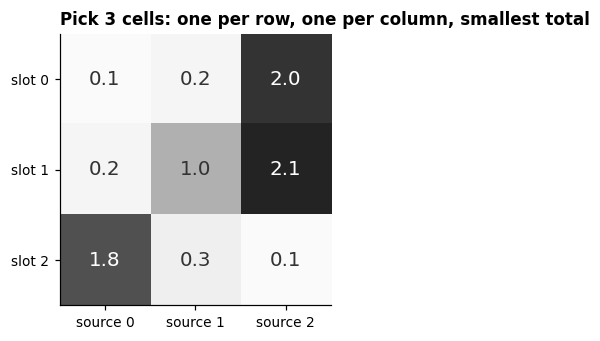

In [6]:
GAME_C = np.array([[0.1, 0.2, 2.0],
                   [0.2, 1.0, 2.1],
                   [1.8, 0.3, 0.1]])

# your picks: (slot, source) pairs — EDIT the source indices, then re-run
my_assignment = [(0, 0), (1, 1), (2, 2)]

fig, ax = plt.subplots(figsize=(3.6, 3.2))
ax.imshow(GAME_C, cmap="Greys", vmin=0, vmax=2.4)
for r in range(3):
    for c_ in range(3):
        ax.text(c_, r, f"{GAME_C[r, c_]:.1f}", ha="center", va="center",
                fontsize=13,
                color="white" if GAME_C[r, c_] > 1.2 else C["ink"])
ax.set_xticks(range(3), [f"source {j}" for j in range(3)])
ax.set_yticks(range(3), [f"slot {i}" for i in range(3)])
ax.grid(False)
title2(ax, "Pick 3 cells: one per row, one per column, smallest total")
plt.tight_layout()

yours:     total 1.2   [(0, 0), (1, 1), (2, 2)]
greedy:    total 1.2   [(0, 0), (1, 1), (2, 2)]
optimal:   total 0.5   [(0, 1), (1, 0), (2, 2)]
→ greedy-or-worse: exactly the trap this section is about
Slot 0's cheapest source (0) is exactly the cell the OPTIMAL assignment gives up
so that slot 1 avoids a 1.0. Hungarian matching is a global optimization, not
'pick the closest source for each slot'.


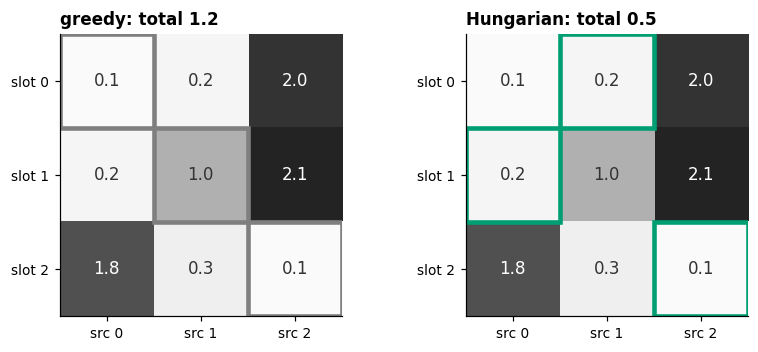

In [7]:
from scipy.optimize import linear_sum_assignment

# score YOUR assignment first
assert sorted(i for i, _ in my_assignment) == [0, 1, 2] and \
       sorted(j for _, j in my_assignment) == [0, 1, 2], \
       "my_assignment must use every slot once and every source once"
my_total = sum(GAME_C[i, j] for i, j in my_assignment)

# greedy: each slot takes the cheapest source still available
taken, greedy = set(), []
for i in range(3):
    j = min((j for j in range(3) if j not in taken),
            key=lambda j: GAME_C[i, j])
    taken.add(j); greedy.append((i, j))
g_total = sum(GAME_C[i, j] for i, j in greedy)

row, col = linear_sum_assignment(GAME_C)
optimal = list(zip(row.tolist(), col.tolist()))
o_total = GAME_C[row, col].sum()

print(f"yours:     total {my_total:.1f}   {my_assignment}")
print(f"greedy:    total {g_total:.1f}   {greedy}")
print(f"optimal:   total {o_total:.1f}   {optimal}")
if abs(my_total - o_total) < 1e-9:
    print("→ you found the optimal assignment 🎉")
elif my_total < g_total:
    print("→ you beat greedy — but the solver still found better")
else:
    print("→ greedy-or-worse: exactly the trap this section is about")

fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.3))
for ax, picks, name, tot, colr in [
        (axes[0], greedy, "greedy", g_total, C["ordered"]),
        (axes[1], optimal, "Hungarian", o_total, C["rescue"])]:
    ax.imshow(GAME_C, cmap="Greys", vmin=0, vmax=2.4)
    for r in range(3):
        for c_ in range(3):
            ax.text(c_, r, f"{GAME_C[r, c_]:.1f}", ha="center", va="center",
                    fontsize=11,
                    color="white" if GAME_C[r, c_] > 1.2 else C["ink"])
    for i, j in picks:
        ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                                   edgecolor=colr, lw=3))
    ax.set_xticks(range(3), [f"src {j}" for j in range(3)])
    ax.set_yticks(range(3), [f"slot {i}" for i in range(3)])
    ax.grid(False)
    title2(ax, f"{name}: total {tot:.1f}")
plt.tight_layout()

print("Slot 0's cheapest source (0) is exactly the cell the OPTIMAL "
      "assignment gives up\nso that slot 1 avoids a 1.0. Hungarian "
      "matching is a global optimization, not\n'pick the closest source "
      "for each slot'.")

## §3b — Implement Hungarian matching  🔧 *the only TODO of the morning*

$$C_{ij} = w_\mu(\hat\mu_i - \mu_j)^2 + w_A(\hat A_i - A_j)^2 ,
\qquad \mathcal{L}_{\rm Hungarian} = \sum_i C_{i,\pi^*(i)},$$

where $\pi^*$ is the minimum-cost assignment from
`scipy.optimize.linear_sum_assignment` — the solver version of what you
just did by hand.

The cost matrix is **given** (read it — one broadcast). Your TODO is the
part that carries the idea: the assignment loop. Two facts to get right
(one line each):
1. The **assignment** is found on a *detached* copy of the cost matrix —
   scipy needs numpy, and an argmin is not differentiable anyway.
2. The **loss** gathers the matched entries of the *live* cost tensor, so
   gradients flow through the matched pairs only.

If you get stuck, the escape-hatch cell below the checks imports the
reference implementation so you can keep moving.

In [8]:
def pairwise_cost(pred, target, w_mu=1.0, w_a=1.0):
    """Cost matrix C[b, i, j] = w_mu*(mu_hat_i - mu_j)^2 + w_a*(A_hat_i - A_j)^2.

    pred, target: (B, K, 2) tensors  ->  return: (B, K, K) tensor,
    C[b, i, j] = cost of explaining true source j with predicted slot i.
    Hint: broadcast pred.unsqueeze(2) against target.unsqueeze(1).
    """
    d = pred.unsqueeze(2) - target.unsqueeze(1)           # (B, K, K, 2)
    return w_mu * d[..., 0] ** 2 + w_a * d[..., 1] ** 2   # (B, K, K)


from scipy.optimize import linear_sum_assignment

def hungarian_loss(pred, target, w_mu=1.0, w_a=1.0):
    """Minimum-cost one-to-one assignment per batch element (see notes above)."""
    cost = pairwise_cost(pred, target, w_mu, w_a)
    total = 0.0
    for b in range(cost.shape[0]):
        # =============== TODO (about 2-3 lines) ==================
        # row, col = linear_sum_assignment(...)   # on WHICH tensor?
        # total = total + ...                     # gathered from WHICH tensor?
        raise NotImplementedError
        # =========================================================
    return total / cost.shape[0]

In [ ]:
# --- Self-check: all four asserts must pass -------------------------------
pc = pairwise_cost(torch.tensor([[[0.3, 1.0], [0.7, 0.5]]]),
                   torch.tensor([[[0.7, 0.5], [0.3, 1.0]]]))
assert torch.allclose(pc[0], torch.tensor([[0.41, 0.0], [0.0, 0.41]])), \
    "cost formula: C[i,j] = (mu_i - mu_j)^2 + (A_i - A_j)^2"

torch.manual_seed(1)
p = torch.randn(4, 2, 2, requires_grad=True)
t = torch.randn(4, 2, 2)

l = hungarian_loss(p, t)
l_perm = hungarian_loss(p, t[:, [1, 0]])
assert torch.allclose(l, l_perm), "loss must be invariant to target order"

c = pairwise_cost(p, t)
brute = (torch.minimum(c[:, 0, 0] + c[:, 1, 1],
                       c[:, 0, 1] + c[:, 1, 0])).mean()
assert torch.allclose(l, brute), "must equal the min over both assignments"

l.backward()
assert p.grad is not None and p.grad.abs().sum() > 0, "gradients must flow"
print("all checks passed ✔  — your loss is permutation-invariant")

In [ ]:
# Stuck? Uncomment the next line to use the reference implementation:
# from toy.model import pairwise_cost, hungarian_loss

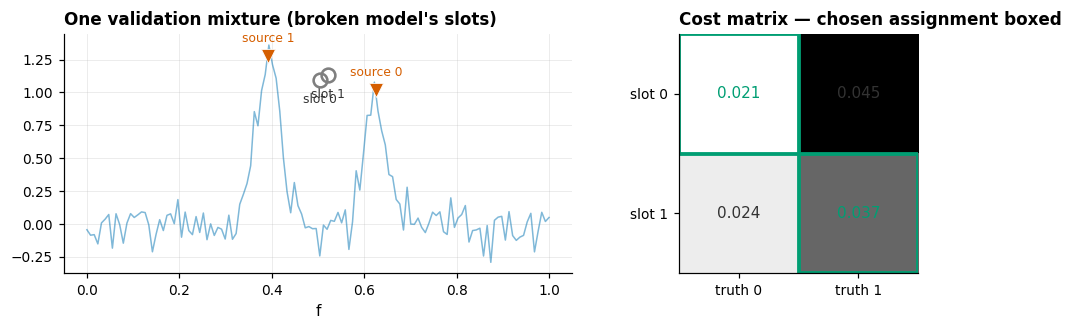

In [11]:
# --- The important part is SEEING the matrix, not calling the function ----
i = 7   # try a few validation examples
with torch.no_grad():
    pred_i = net_ordered(Xv[i:i + 1])[0]
cost_i = pairwise_cost(pred_i.unsqueeze(0), Tv[i:i + 1])[0]
row, col = linear_sum_assignment(cost_i.numpy())

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9, 3.1),
                               gridspec_kw={"width_ratios": [1.5, 1]})
ax0.plot(FREQ_AXIS, Xv[i], lw=1, color=C["pred"], alpha=0.5)
for j, (mu, A) in enumerate(Tv[i]):
    mark_truth(ax0, mu, A)
    ax0.annotate(f"source {j}", (mu, A), color=C["truth"],
                 xytext=(0, 9), textcoords="offset points", ha="center",
                 fontsize=8)
for s, (mu, A) in enumerate(pred_i):
    mark_pred(ax0, mu, A, color=C["ordered"])
    ax0.annotate(f"slot {s}", (mu, A), color=C["ink"],
                 xytext=(0, -15), textcoords="offset points", ha="center",
                 fontsize=8)
ax0.set_xlabel("f")
title2(ax0, "One validation mixture (broken model's slots)")

ax1.imshow(cost_i, cmap="Greys")
for r, c_ in zip(row, col):
    ax1.add_patch(plt.Rectangle((c_ - 0.5, r - 0.5), 1, 1, fill=False,
                                edgecolor=C["rescue"], lw=2.5))
for r in range(2):
    for c_ in range(2):
        ax1.text(c_, r, f"{cost_i[r, c_]:.3f}", ha="center", va="center",
                 color=C["rescue"] if (r, c_) in zip(row, col) else C["ink"])
ax1.set_xticks([0, 1], ["truth 0", "truth 1"])
ax1.set_yticks([0, 1], ["slot 0", "slot 1"])
ax1.grid(False)
title2(ax1, "Cost matrix — chosen assignment boxed")
plt.tight_layout()

## §4 — Train the permutation-invariant model

Same architecture, fresh initialization, *your* Hungarian loss. Watch the
matched validation curve: it should fall well below the ordered plateau,
because the network no longer has to hedge between the two labelings.

In [12]:
torch.manual_seed(0)
net_hung = ToySlotNet()
if TRAIN_LIVE:
    hist_hung = fit(net_hung, hungarian_loss, tag="hungarian")
else:
    ck = torch.load("toy/data/after_hungarian.pt", weights_only=False)
    net_hung.load_state_dict(ck["state_dict"])
    hist_hung = None
    print("loaded staged checkpoint (30 epochs)")

with torch.no_grad():
    for name, net in [("ordered  ", net_ordered), ("hungarian", net_hung)]:
        val = hungarian_loss(net(Xv), Tv).item()
        val_perm = hungarian_loss(net(Xv), Tv[:, [1, 0]]).item()
        print(f"{name}: matched val loss {val:.4f}   "
              f"after permuting labels {val_perm:.4f}")

  [hungarian] epoch  1/12   train 0.3933   matched val 0.1526
  [hungarian] epoch  2/12   train 0.1026   matched val 0.0859
  [hungarian] epoch  4/12   train 0.0485   matched val 0.0421
  [hungarian] epoch  8/12   train 0.0245   matched val 0.0239
  [hungarian] epoch 12/12   train 0.0199   matched val 0.0203
ordered  : matched val loss 0.1285   after permuting labels 0.1285
hungarian: matched val loss 0.0209   after permuting labels 0.0209


slot separation — ordered: 0.033   hungarian: 0.239   truth: 0.269


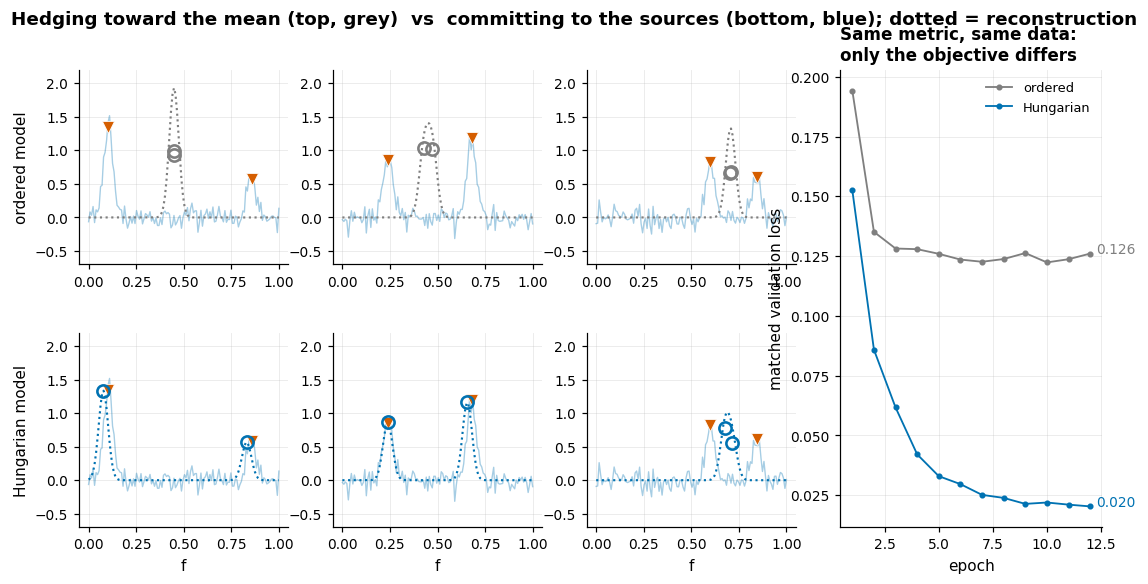

In [13]:
# --- The comparison figure: same mixtures, both models, one look ----------
with torch.no_grad():
    P_ord = net_ordered(Xv[:200])
    P_hun = net_hung(Xv[:200])

sep_true = (Tv[:200, 0, 0] - Tv[:200, 1, 0]).abs()
examples = np.argsort(-sep_true.numpy())[[3, 40, 90]]   # separated -> closer

fig = plt.figure(figsize=(12, 5.4))
gs = fig.add_gridspec(2, 4, width_ratios=[1, 1, 1, 1.25], hspace=0.35)
for col, i in enumerate(examples):
    for rowi, (P, name, colr) in enumerate(
            [(P_ord, "ordered", C["ordered"]),
             (P_hun, "Hungarian", C["pred"])]):
        ax = fig.add_subplot(gs[rowi, col])
        ax.plot(FREQ_AXIS, Xv[i], lw=0.9, color=C["pred"], alpha=0.35)
        ax.plot(FREQ_AXIS, render(P[i].numpy()), ls=":", lw=1.4, color=colr)
        for mu, A in Tv[i]:
            mark_truth(ax, mu, A, ms=8)
        for mu, A in P[i]:
            mark_pred(ax, mu, A, color=colr, ms=8)
        ax.set_ylim(-0.7, 2.2)
        if col == 0:
            ax.set_ylabel(f"{name} model")
        if rowi == 1:
            ax.set_xlabel("f")

ax = fig.add_subplot(gs[:, 3])
if hist_ordered is not None:
    ep = np.arange(1, len(hist_ordered["val"]) + 1)
    ax.plot(ep, hist_ordered["val"], color=C["ordered"], marker=".",
            label="ordered")
    ax.plot(ep, hist_hung["val"], color=C["pred"], marker=".",
            label="Hungarian")
    ax.annotate(f'{hist_ordered["val"][-1]:.3f}',
                (ep[-1], hist_ordered["val"][-1]), xytext=(4, 0),
                textcoords="offset points", color=C["ordered"], fontsize=9)
    ax.annotate(f'{hist_hung["val"][-1]:.3f}',
                (ep[-1], hist_hung["val"][-1]), xytext=(4, 0),
                textcoords="offset points", color=C["pred"], fontsize=9)
    ax.legend()
else:
    ax.text(0.5, 0.5, "training curves are recorded\nwhen TRAIN_LIVE=True",
            ha="center", va="center", transform=ax.transAxes, fontsize=9,
            color=C["ink"])
ax.set_xlabel("epoch"); ax.set_ylabel("matched validation loss")
title2(ax, "Same metric, same data:\nonly the objective differs")

with torch.no_grad():
    gap_h = (net_hung(Xv)[:, 0, 0] - net_hung(Xv)[:, 1, 0]).abs().mean()
gap_t = (Tv[:, 0, 0] - Tv[:, 1, 0]).abs().mean()
fig.suptitle("Hedging toward the mean (top, grey)  vs  committing to the "
             "sources (bottom, blue); dotted = reconstruction",
             fontweight="semibold")
print(f"slot separation — ordered: {(P_ord[:, 0, 0]-P_ord[:, 1, 0]).abs().mean():.3f}"
      f"   hungarian: {gap_h:.3f}   truth: {gap_t:.3f}")

## §5 — When does the assignment become ambiguous?  *(presenter-driven, ~4′)*

Watch the projector for this one (run the widget yourself later — every
slider move is true inference). Intuition says: "move the peaks together
and matching breaks." The truth is sharper:

> **Frequency overlap alone does not create assignment ambiguity.
> Ambiguity appears when the sources become indistinguishable under the
> COMPLETE matching metric** — two coincident peaks with clearly different
> amplitudes are still perfectly assignable.

The diagnostic: with K=2 there are exactly **two** possible assignments,
with totals $C_{00}{+}C_{11}$ and $C_{01}{+}C_{10}$ — the **assignment
margin** is just their difference (best vs second-best). The title reports
it under two metrics at once: the full (μ, A) cost and frequency-only.
Drag the separation down at equal amplitudes and both margins collapse;
raise the amplitude ratio and the full-metric margin comes back while the
frequency-only margin stays dead. (A systematic sweep of this experiment
lives in the take-home appendix.)

interactive(children=(FloatSlider(value=0.25, description='sep', max=0.4, step=0.01), FloatSlider(value=1.0, d…

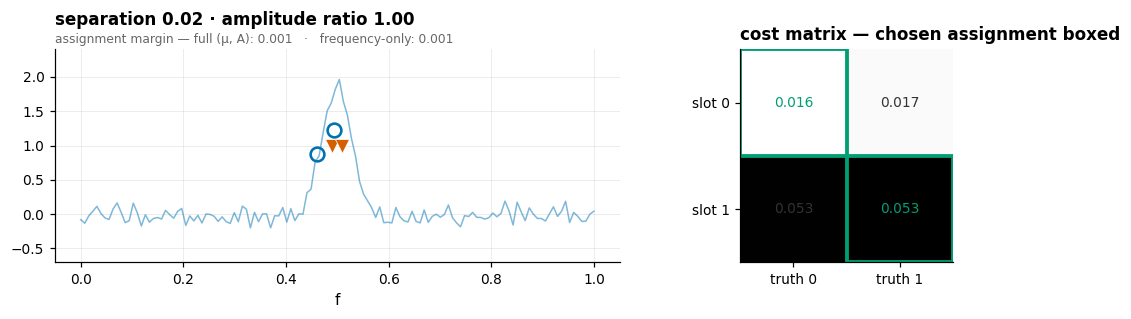

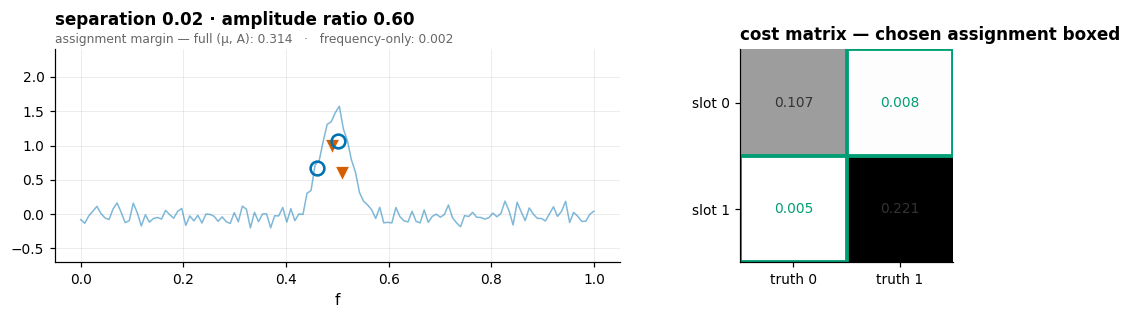

In [14]:
# --- Interactive: move the sources together (TRUE inference on every move —
#     a fresh mixture is rendered, net_hung runs a real forward pass, and
#     the real Hungarian assignment is solved) ------------------------------
from toy.simulator import render, NOISE_STD


def probe(sep=0.25, amp_ratio=1.0, noise=NOISE_STD, seed=5):
    rng_i = np.random.default_rng(seed)
    theta = np.array([[0.5 - sep / 2, 1.0],
                      [0.5 + sep / 2, amp_ratio]], np.float32)
    x = render(theta) + rng_i.normal(0, noise, len(FREQ_AXIS)).astype(np.float32)
    with torch.no_grad():
        pred = net_hung(torch.from_numpy(x).unsqueeze(0))[0]
    tt = torch.from_numpy(theta).unsqueeze(0)
    cost = pairwise_cost(pred.unsqueeze(0), tt)[0]
    cost_f = pairwise_cost(pred.unsqueeze(0), tt, 1.0, 0.0)[0]
    m_full = abs(float(cost[0, 0] + cost[1, 1] - cost[0, 1] - cost[1, 0]))
    m_freq = abs(float(cost_f[0, 0] + cost_f[1, 1] - cost_f[0, 1] - cost_f[1, 0]))
    row, col = linear_sum_assignment(cost.numpy())

    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9.5, 3),
                                   gridspec_kw={"width_ratios": [1.6, 1]})
    ax0.plot(FREQ_AXIS, x, lw=1, color=C["pred"], alpha=0.5)
    for mu, A in theta:
        mark_truth(ax0, mu, A)
    for mu, A in pred:
        mark_pred(ax0, mu, A)
    ax0.set_ylim(-0.7, 2.4); ax0.set_xlabel("f")
    title2(ax0, f"separation {sep:.2f} · amplitude ratio {amp_ratio:.2f}",
           f"assignment margin — full (μ, A): {m_full:.3f}   ·   "
           f"frequency-only: {m_freq:.3f}")

    ax1.imshow(cost, cmap="Greys")
    for r, c_ in zip(row, col):
        ax1.add_patch(plt.Rectangle((c_ - 0.5, r - 0.5), 1, 1, fill=False,
                                    edgecolor=C["rescue"], lw=2.5))
    for r in range(2):
        for c_ in range(2):
            ax1.text(c_, r, f"{cost[r, c_]:.3f}", ha="center", va="center",
                     fontsize=9,
                     color=C["rescue"] if (r, c_) in zip(row, col)
                     else C["ink"])
    ax1.set_xticks([0, 1], ["truth 0", "truth 1"])
    ax1.set_yticks([0, 1], ["slot 0", "slot 1"]); ax1.grid(False)
    title2(ax1, "cost matrix — chosen assignment boxed")
    plt.tight_layout(); plt.show()


try:
    from ipywidgets import interact, FloatSlider
    interact(probe,
             sep=FloatSlider(0.25, min=0.0, max=0.4, step=0.01),
             amp_ratio=FloatSlider(1.0, min=0.4, max=1.6, step=0.05),
             noise=FloatSlider(NOISE_STD, min=0.0, max=0.4, step=0.02),
             seed=(0, 20))
    # static reference frames (widget state is not saved with the file):
    # the two states that carry the lesson —
    probe(sep=0.02, amp_ratio=1.0)   # coincident + equal amps: ambiguous
    probe(sep=0.02, amp_ratio=0.6)   # coincident + unequal: still assignable
except ImportError:
    print("ipywidgets unavailable — three snapshots instead:")
    for sep, ar in [(0.25, 1.0), (0.02, 1.0), (0.02, 0.5)]:
        probe(sep=sep, amp_ratio=ar)

## §6 — Takeaways

1. **Catalogues are unordered.**
2. **Slot indices are arbitrary.**
3. **Training *and evaluation* must both account for permutation.**
4. **Matching becomes ambiguous only when sources become indistinguishable
   under the complete metric.**

The concept map below is the whole morning in one picture — and the bridge
to this afternoon, where the number of sources itself becomes unknown.

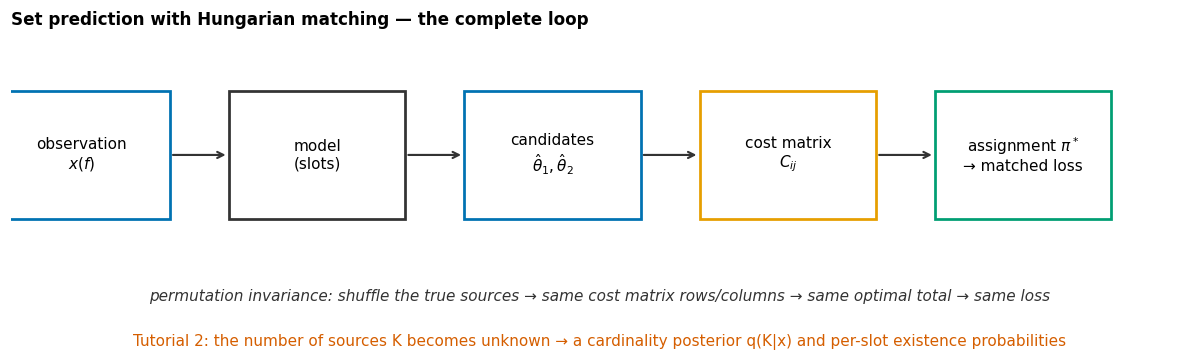

In [15]:
# --- Concept map: the whole pipeline in one picture ------------------------
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.axis("off")

boxes = [
    (0.06, "observation\n$x(f)$", C["pred"]),
    (0.26, "model\n(slots)", C["ink"]),
    (0.46, "candidates\n$\\hat\\theta_1, \\hat\\theta_2$", C["pred"]),
    (0.66, "cost matrix\n$C_{ij}$", C["gold"]),
    (0.86, "assignment $\\pi^*$\n→ matched loss", C["rescue"]),
]
for xc, lbl, colr in boxes:
    ax.add_patch(plt.Rectangle((xc - 0.075, 0.42), 0.15, 0.4,
                               facecolor="white", edgecolor=colr, lw=1.8))
    ax.text(xc, 0.62, lbl, ha="center", va="center", fontsize=10)
for x0, x1 in [(0.135, 0.185), (0.335, 0.385), (0.535, 0.585),
               (0.735, 0.785)]:
    ax.annotate("", xy=(x1, 0.62), xytext=(x0, 0.62),
                arrowprops=dict(arrowstyle="->", color=C["ink"], lw=1.4))

ax.text(0.5, 0.16,
        "permutation invariance: shuffle the true sources → same cost "
        "matrix rows/columns → same optimal total → same loss",
        ha="center", fontsize=10, style="italic", color=C["ink"])
ax.text(0.5, 0.02,
        "Tutorial 2: the number of sources K becomes unknown → a "
        "cardinality posterior q(K|x) and per-slot existence probabilities",
        ha="center", fontsize=10, color=C["truth"])
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
title2(ax, "Set prediction with Hungarian matching — the complete loop")
plt.tight_layout()

### Optional take-home: unknown K on the toy

Real catalogues don't come with K attached. Extend the toy to
$K \in \{0,1,2,3\}$ with $M{=}3$ slots, each predicting
$(\hat p_i, \hat\mu_i, \hat A_i)$ where $\hat p_i$ is an **existence
probability**, and train with

$$\mathcal{L} = \sum_{(i,j)\in\pi^*} c(\hat\theta_i, \theta_j)
\; + \; \lambda\,\textstyle\sum_i \mathrm{BCE}(\hat p_i, y_i),$$

where $y_i = 1$ iff slot $i$ was matched to a true source. Everything you
need is already in this notebook. In Tutorial 2 you will meet the *other*
way to make K a prediction: a categorical posterior $q(K\mid x)$ — and
you will derive per-slot existence probabilities from it.

### One question to carry into Tutorial 2

Look back at the equal-amplitude, near-zero-separation corner of §5. When
the model "gets it wrong" there — is that a **model failure**, a
**loss/matching failure**, an **evaluation failure**, or an
**intrinsically ambiguous observation**?

$$\text{representation} \neq \text{inference} \neq \text{matching}
\neq \text{decision} \neq \text{evaluation}$$

Keeping those apart is the real skill this workshop is about, and
Tutorial 2 will test it on a model you did not train.

---
## Appendix — take-home: the ambiguity experiment, systematically

The widget shows single frames; this cell measures the same effect over
thousands of mixtures — assignment margin vs true separation, with
equal- vs unequal-amplitude pairs as separate curves.

Equal-amplitude pairs: the margin collapses toward zero as the peaks merge —
genuine ambiguity. Unequal-amplitude pairs stay assignable at zero separation:
the amplitude coordinate resolves the assignment. Ambiguity = indistinguishability
under the FULL metric, not frequency crowding per se.


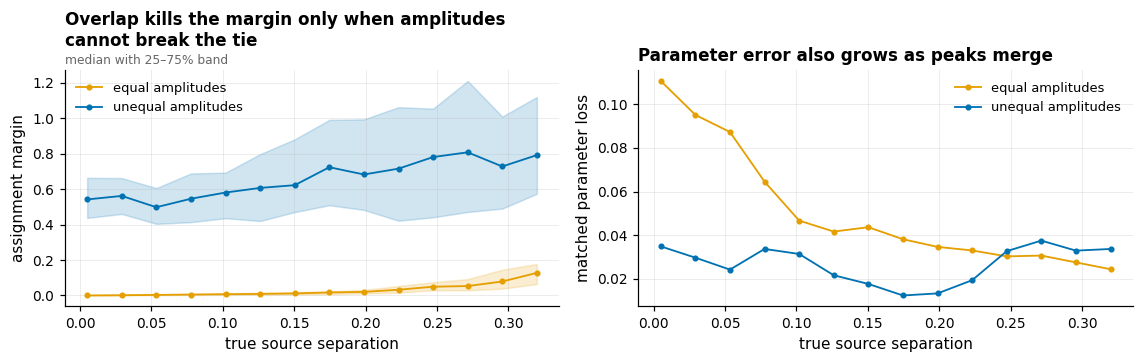

In [16]:
# --- Systematic version: margin vs separation, equal vs unequal amplitudes
def margin_curve(amp_mode, n=150, seed=11):
    rng_s = np.random.default_rng(seed)
    seps = np.linspace(0.005, 0.32, 14)
    med, lo, hi, err = [], [], [], []
    for sep in seps:
        thetas, xs = [], []
        for _ in range(n):
            mu0 = rng_s.uniform(0.15, 0.85 - sep)
            if amp_mode == "equal":
                a = rng_s.uniform(0.7, 1.3)
                amps = (a, a)
            else:
                amps = (rng_s.uniform(1.1, 1.5), rng_s.uniform(0.5, 0.9))
            th = np.array([[mu0, amps[0]], [mu0 + sep, amps[1]]], np.float32)
            thetas.append(th)
            xs.append(render(th) + rng_s.normal(0, NOISE_STD, len(FREQ_AXIS))
                      .astype(np.float32))
        Xs = torch.from_numpy(np.stack(xs))
        Ts = torch.from_numpy(np.stack(thetas))
        with torch.no_grad():
            Ps = net_hung(Xs)
            cc = pairwise_cost(Ps, Ts)
            e = hungarian_loss(Ps, Ts).item()
        m = (cc[:, 0, 0] + cc[:, 1, 1] - cc[:, 0, 1] - cc[:, 1, 0]).abs().numpy()
        med.append(np.median(m)); lo.append(np.percentile(m, 25))
        hi.append(np.percentile(m, 75)); err.append(e)
    return seps, np.array(med), np.array(lo), np.array(hi), np.array(err)


fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10.5, 3.4))
for mode, colr, lbl in [("equal", C["gold"], "equal amplitudes"),
                        ("unequal", C["pred"], "unequal amplitudes")]:
    s, m, lo, hi, e = margin_curve(mode)
    ax0.plot(s, m, color=colr, marker=".", label=lbl)
    ax0.fill_between(s, lo, hi, color=colr, alpha=0.18)
    ax1.plot(s, e, color=colr, marker=".", label=lbl)
ax0.set_xlabel("true source separation"); ax0.set_ylabel("assignment margin")
ax0.legend()
title2(ax0, "Overlap kills the margin only when amplitudes\n"
       "cannot break the tie", "median with 25–75% band")
ax1.set_xlabel("true source separation")
ax1.set_ylabel("matched parameter loss")
title2(ax1, "Parameter error also grows as peaks merge")
ax1.legend()
plt.tight_layout()

print("Equal-amplitude pairs: the margin collapses toward zero as the "
      "peaks merge —\ngenuine ambiguity. Unequal-amplitude pairs stay "
      "assignable at zero separation:\nthe amplitude coordinate resolves "
      "the assignment. Ambiguity = indistinguishability\nunder the FULL "
      "metric, not frequency crowding per se.")